## Analysing the extracted data to be used to fit the transfer functions of FS and RS neurons.

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we analyse the exctracted data to be used for the fitting of the transfer functions obtained running the files *TF_data_extraction_FS.py*, and *TF_data_extraction_RS.py*.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Brian_function_helper import *
from utils.Plots_helper import *

In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 


In [5]:
simulation_folders = ['TF_FS_v1', 'TF_RS_delay_v1', 'TF_RS_no_adapt_v1']

fig_name = 'Analysing_TF_data_extraction_3_neuron_types'

### Plotting the firing frequency as function of the Poissonian input

#### FS

In [6]:
# --- Load the data ---
df_FS = pd.read_csv(
    os.path.join('simulations', simulation_folders[0], 'testing_TF_data_FS.dat'),
    delim_whitespace=True,
    header=0
)

In [7]:
inh_vals = sorted(df_FS['input_inh'].unique())
exc_vals = sorted(df_FS['input_exc'].unique())


In [8]:
print(f'These are the values in Hz of the inhibitory and excitatory Poissonian stimulation on FS \ninh: {inh_vals}, \nexc: {exc_vals}')


These are the values in Hz of the inhibitory and excitatory Poissonian stimulation on FS 
inh: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0], 
exc: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0]


In [9]:
# Slicing the data
x_s = sorted(df_FS['input_exc'].unique())
y_s = sorted(df_FS['input_inh'].unique())

df_FS_slice_array = df_FS['avg_f_out'].to_numpy().reshape(len(y_s), len(x_s))
df_std_FS_slice_array = df_FS['std_f_out'].to_numpy().reshape(len(y_s), len(x_s))

'''
# Calling the plotting functions defined in Plots_helper.py
fig, ax = plt.subplots(figsize=(10,6))
im, cbar = heatmap_vars(df_FS_slice_array,
                    row_labels = y_s,
                    col_labels = x_s,
                    ax=ax,
                    cmap="Reds",
                    cbarlabel="Output frequency (Hz)",
                    plt_title=f'FS output firing rate (Hz)',
                    x_lab = 'Freq Excitatory synapses (Hz)',
                    y_lab = 'Freq Inhibitory synapses (Hz)')
#texts = annotate_heatmap(im, valfmt="{x:.1f} Hz")
figs.append(fig)
'''

'\n# Calling the plotting functions defined in Plots_helper.py\nfig, ax = plt.subplots(figsize=(10,6))\nim, cbar = heatmap_vars(df_FS_slice_array,\n                    row_labels = y_s,\n                    col_labels = x_s,\n                    ax=ax,\n                    cmap="Reds",\n                    cbarlabel="Output frequency (Hz)",\n                    plt_title=f\'FS output firing rate (Hz)\',\n                    x_lab = \'Freq Excitatory synapses (Hz)\',\n                    y_lab = \'Freq Inhibitory synapses (Hz)\')\n#texts = annotate_heatmap(im, valfmt="{x:.1f} Hz")\nfigs.append(fig)\n'

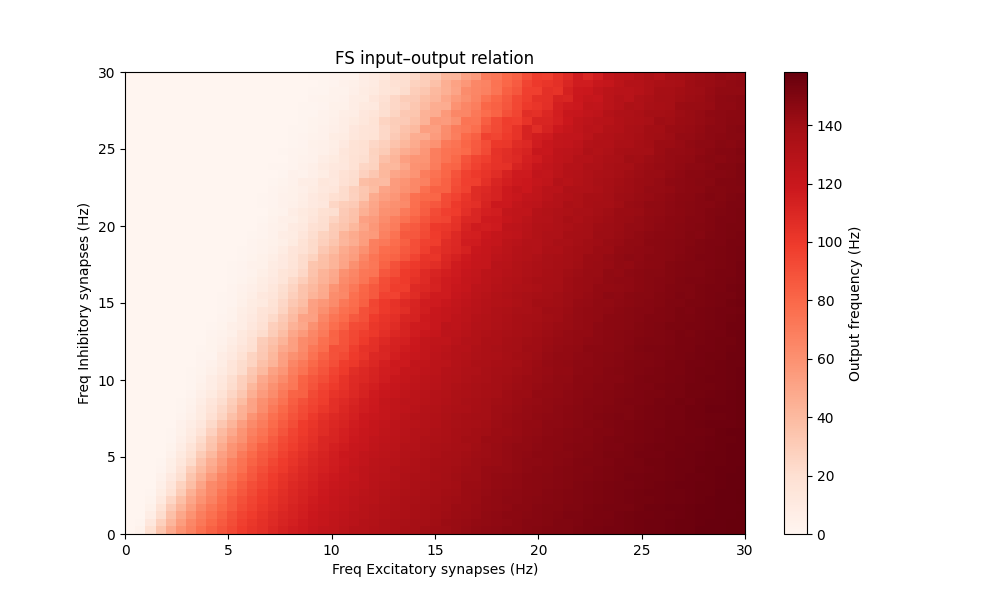

In [10]:
fig = heatmap_InOut(exc_vals, inh_vals, df_FS_slice_array, neuron_type='FS')
figs.append(fig)

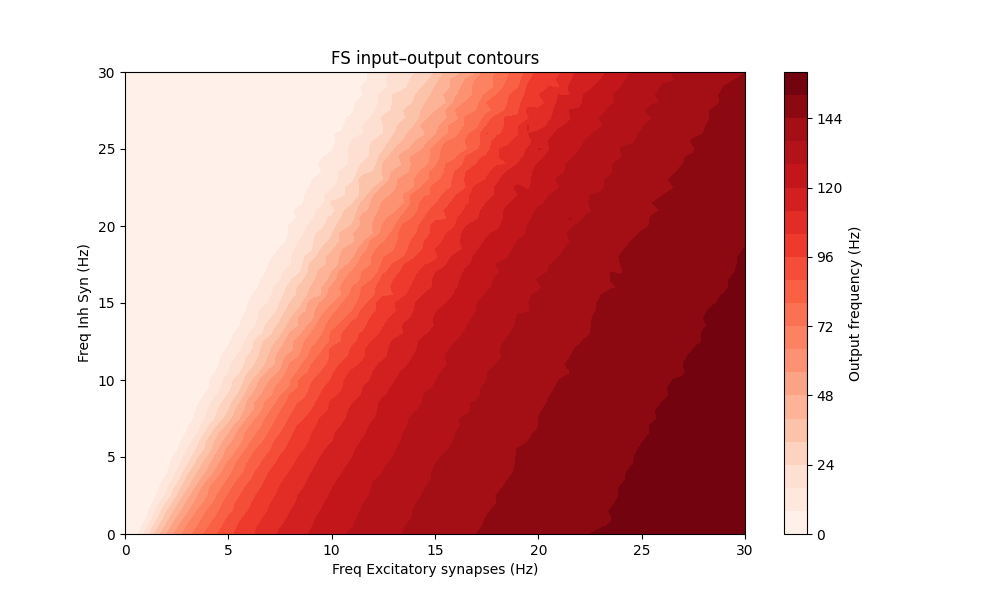

In [11]:
fig = plot_contours(exc_vals, inh_vals, df_FS_slice_array, neuron_type='FS')
figs.append(fig)

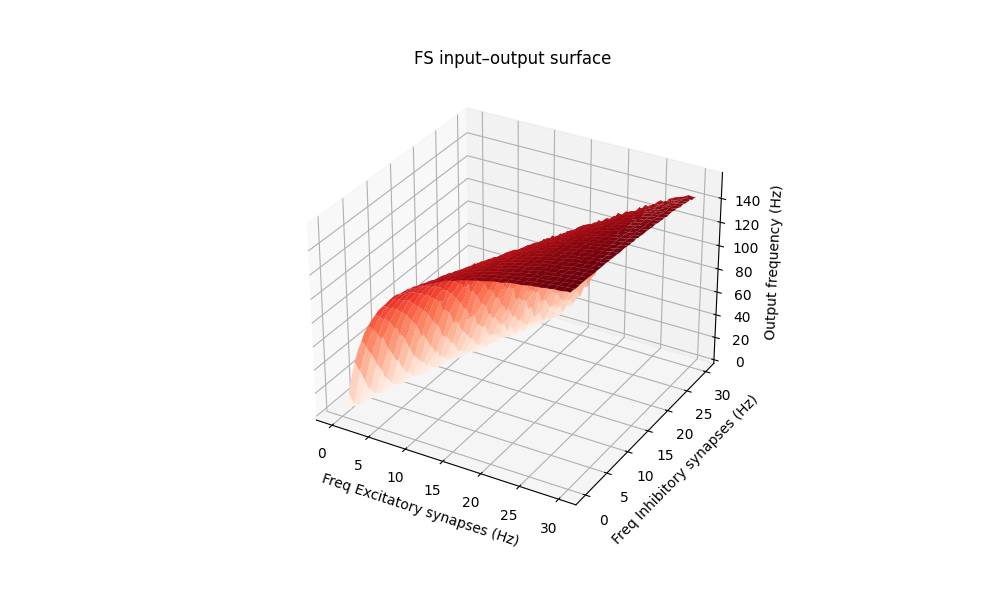

In [12]:
fig = mesh_3d(exc_vals, inh_vals, df_FS_slice_array, neuron_type='FS')
figs.append(fig)

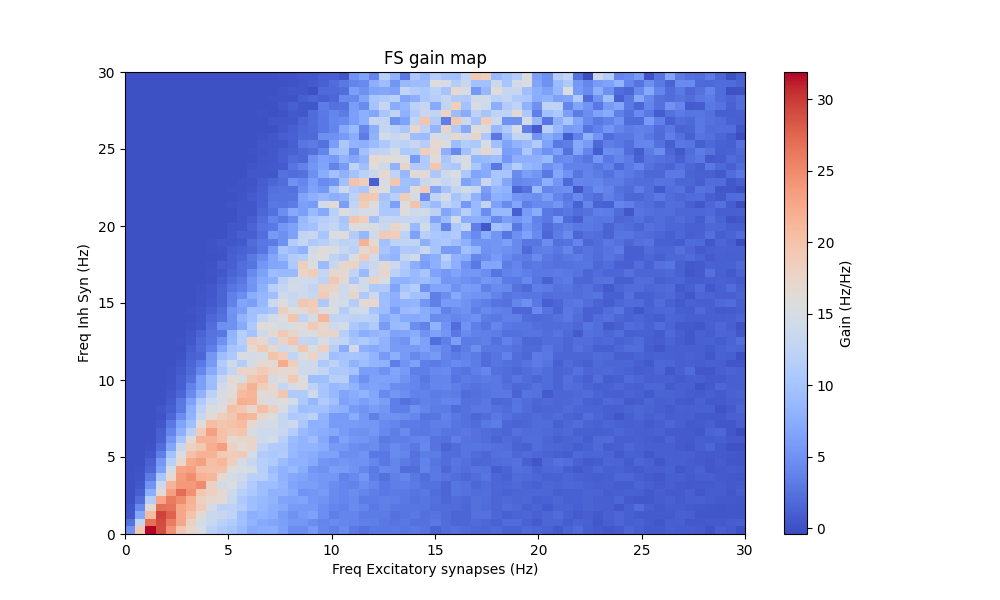

In [13]:
fig = plot_gain(exc_vals, inh_vals, df_FS_slice_array, neuron_type='FS')
figs.append(fig)

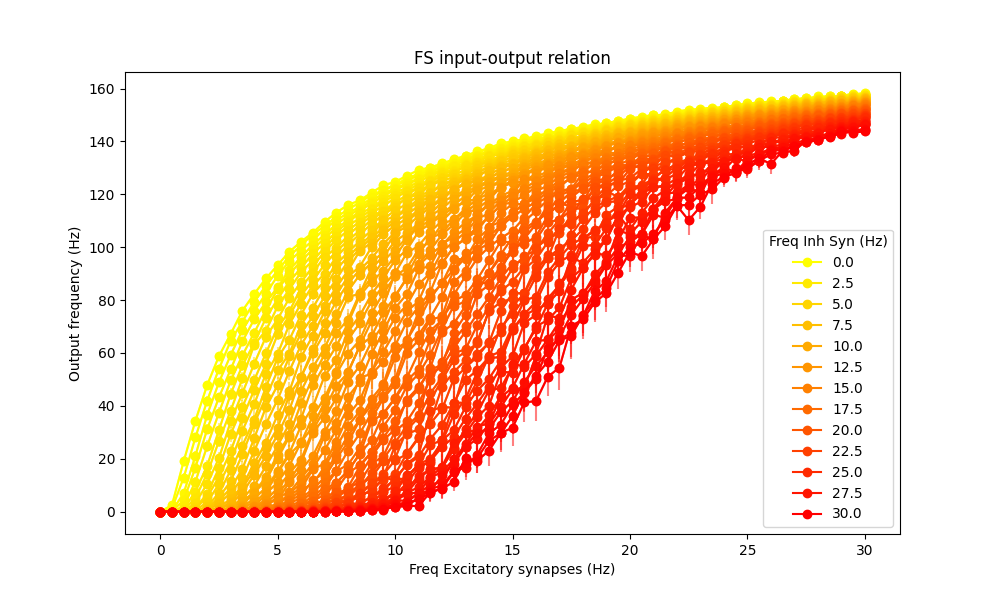

In [14]:
fig = plot_InOut_relation(exc_vals, inh_vals, df_FS_slice_array, df_std_FS_slice_array, neuron_type='FS')
figs.append(fig)

#### RS (with adaptation)

In [15]:
# --- Load the data ---
df_RS = pd.read_csv(
    os.path.join('simulations',simulation_folders[1], 'testing_TF_data_RS.dat'),
    delim_whitespace=True,
    header=0
)

In [16]:
inh_vals = sorted(df_RS['input_inh'].unique())
exc_vals = sorted(df_RS['input_exc'].unique())


In [17]:
print(f'These are the values in Hz of the inhibitory and excitatory Poissonian stimulation on RS \ninh: {inh_vals}, \nexc: {exc_vals}')


These are the values in Hz of the inhibitory and excitatory Poissonian stimulation on RS 
inh: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0], 
exc: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0]


In [18]:
# Slicing the data
x_s = sorted(df_RS['input_exc'].unique())
y_s = sorted(df_RS['input_inh'].unique())

df_RS_slice_array = df_RS['avg_f_out'].to_numpy().reshape(len(y_s), len(x_s))
df_std_RS_slice_array = df_RS['std_f_out'].to_numpy().reshape(len(y_s), len(x_s))

'''
# Calling the plotting functions defined in Plots_helper.py
fig, ax = plt.subplots(figsize=(10,6))
im, cbar = heatmap_vars(df_RS_slice_array,
                    row_labels = y_s,
                    col_labels = x_s,
                    ax=ax,
                    cmap="Greens",
                    cbarlabel="Output frequency (Hz)",
                    plt_title=f'RS output firing rate (Hz)',
                    x_lab = 'Freq Excitatory synapses',
                    y_lab = 'Freq Inhibitory synapses')
#texts = annotate_heatmap(im, valfmt="{x:.1f} Hz")
figs.append(fig)
'''

'\n# Calling the plotting functions defined in Plots_helper.py\nfig, ax = plt.subplots(figsize=(10,6))\nim, cbar = heatmap_vars(df_RS_slice_array,\n                    row_labels = y_s,\n                    col_labels = x_s,\n                    ax=ax,\n                    cmap="Greens",\n                    cbarlabel="Output frequency (Hz)",\n                    plt_title=f\'RS output firing rate (Hz)\',\n                    x_lab = \'Freq Excitatory synapses\',\n                    y_lab = \'Freq Inhibitory synapses\')\n#texts = annotate_heatmap(im, valfmt="{x:.1f} Hz")\nfigs.append(fig)\n'

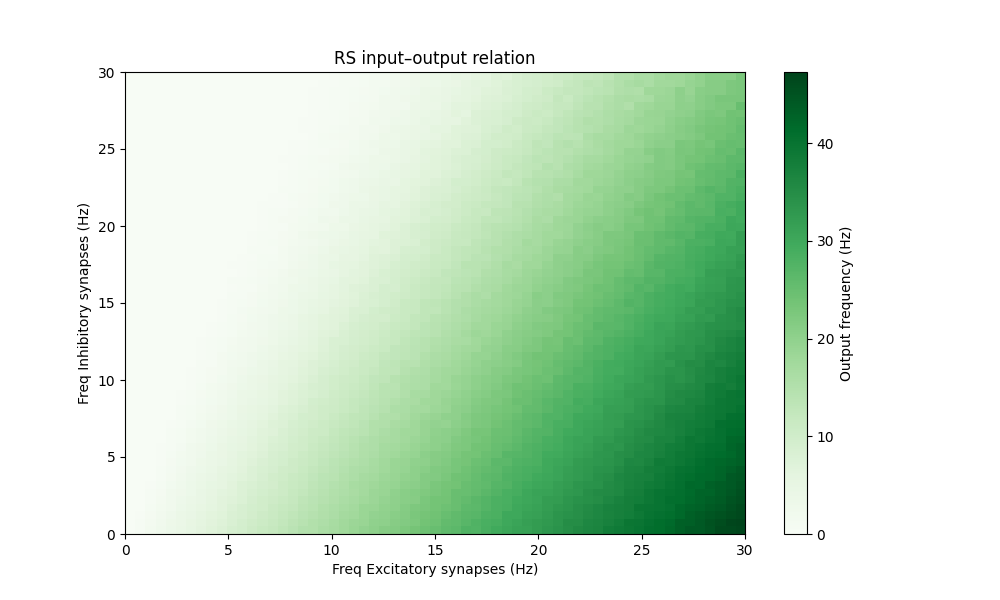

In [19]:
fig = heatmap_InOut(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS')
figs.append(fig)

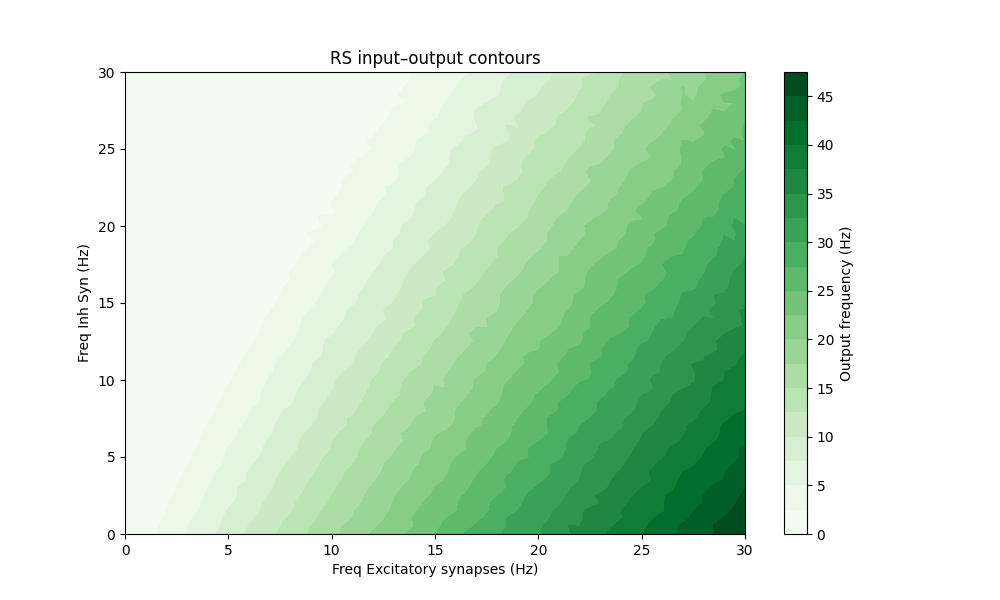

In [20]:
fig = plot_contours(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS')
figs.append(fig)

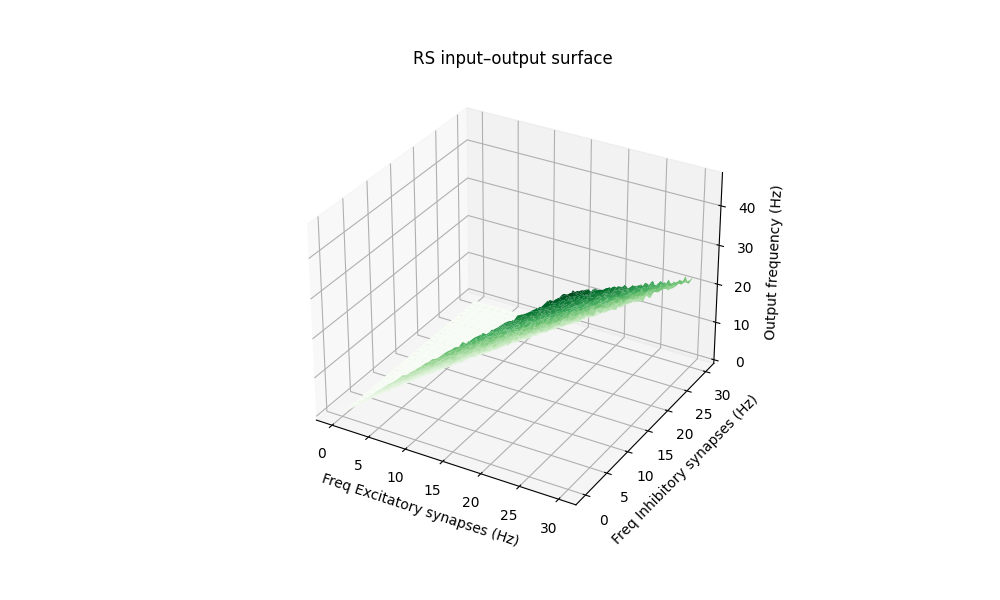

In [21]:
fig = mesh_3d(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS')
figs.append(fig)

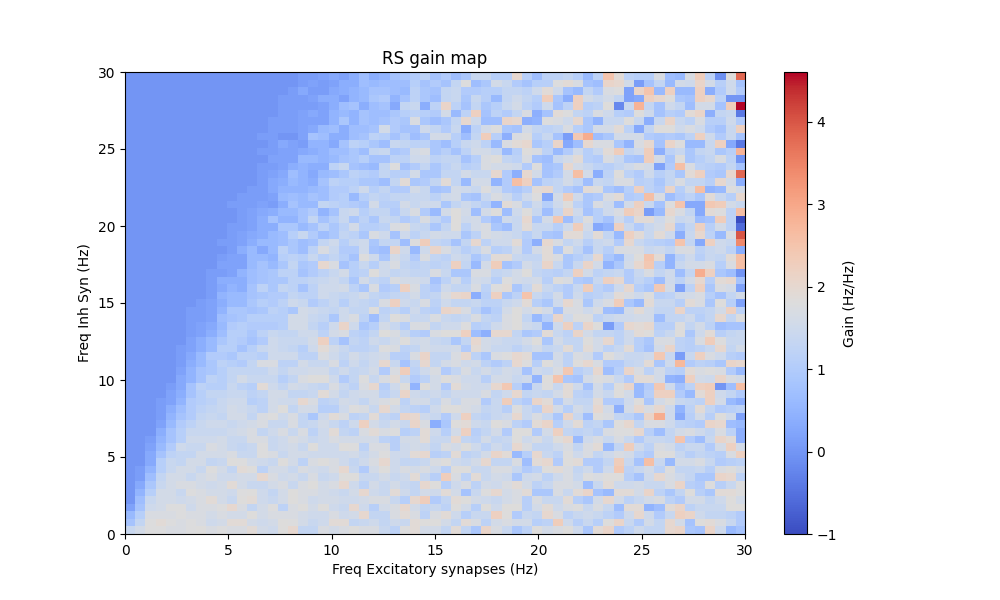

In [22]:
fig = plot_gain(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS')
figs.append(fig)

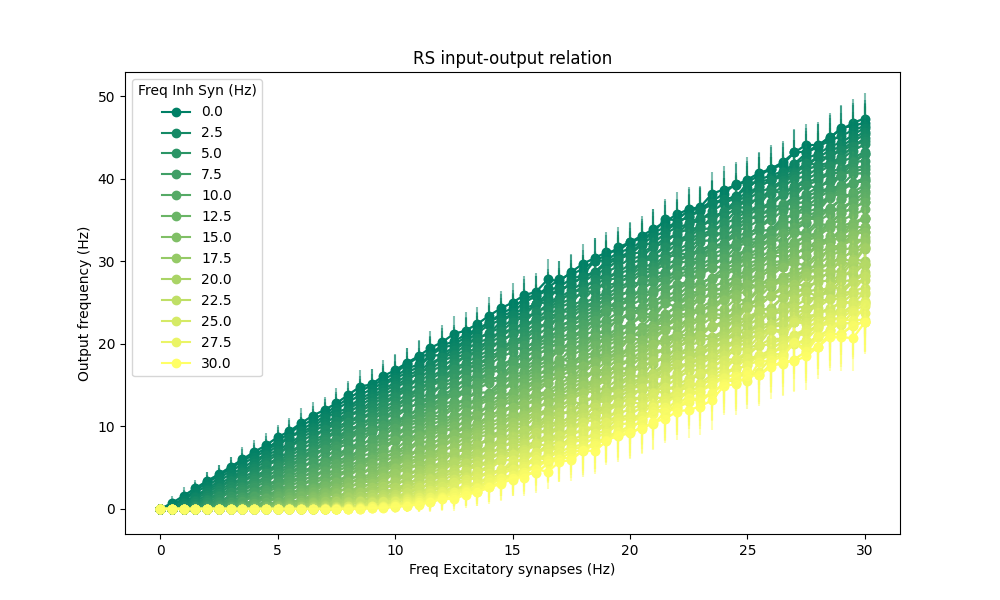

In [23]:
fig = plot_InOut_relation(exc_vals, inh_vals, df_RS_slice_array, df_std_RS_slice_array, neuron_type='RS')
figs.append(fig)

#### RS (without adaptation)

In [24]:
# --- Load the data ---
df_RS = pd.read_csv(
    os.path.join('simulations',simulation_folders[2], 'testing_TF_data_RS.dat'),
    delim_whitespace=True,
    header=0
)

In [25]:
inh_vals = sorted(df_RS['input_inh'].unique())
exc_vals = sorted(df_RS['input_exc'].unique())


In [26]:
print(f'These are the values in Hz of the inhibitory and excitatory Poissonian stimulation on RS \ninh: {inh_vals}, \nexc: {exc_vals}')


These are the values in Hz of the inhibitory and excitatory Poissonian stimulation on RS 
inh: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0], 
exc: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0]


In [27]:
# Slicing the data
x_s = sorted(df_RS['input_exc'].unique())
y_s = sorted(df_RS['input_inh'].unique())

df_RS_slice_array = df_RS['avg_f_out'].to_numpy().reshape(len(y_s), len(x_s))
df_std_RS_slice_array = df_RS['std_f_out'].to_numpy().reshape(len(y_s), len(x_s))


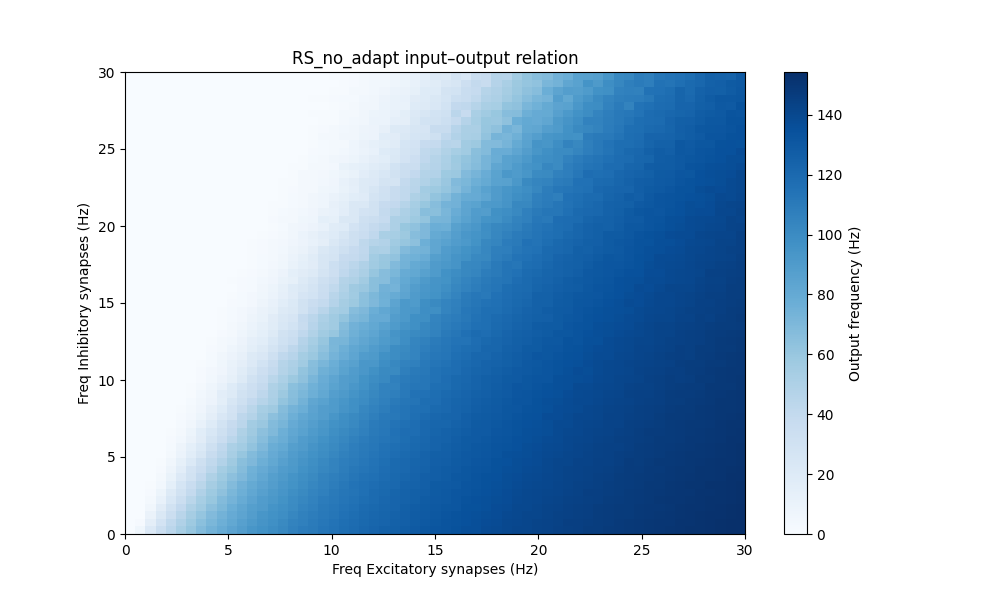

In [28]:
fig = heatmap_InOut(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS_no_adapt')
figs.append(fig)

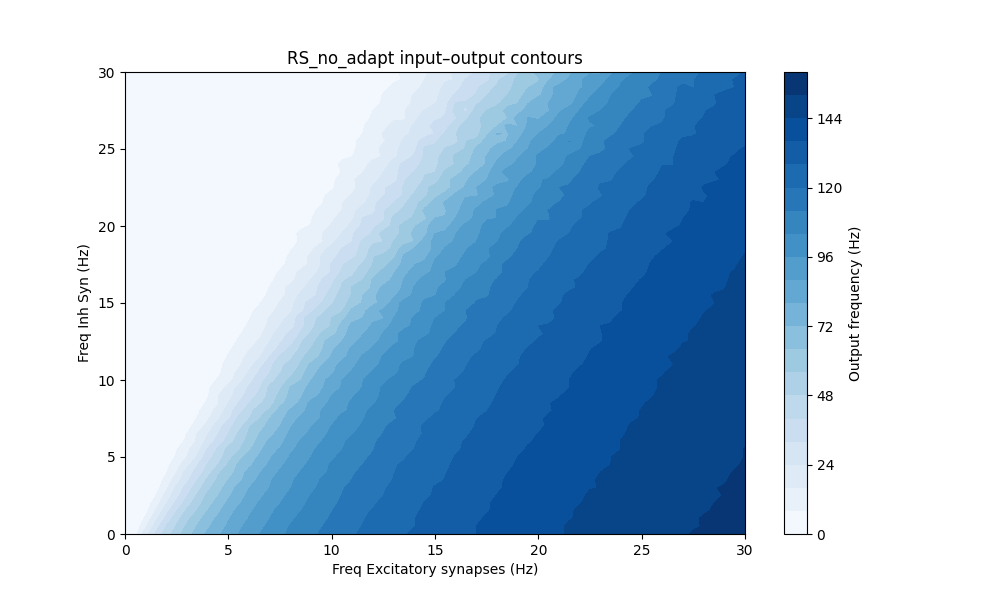

In [29]:
fig = plot_contours(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS_no_adapt')
figs.append(fig)

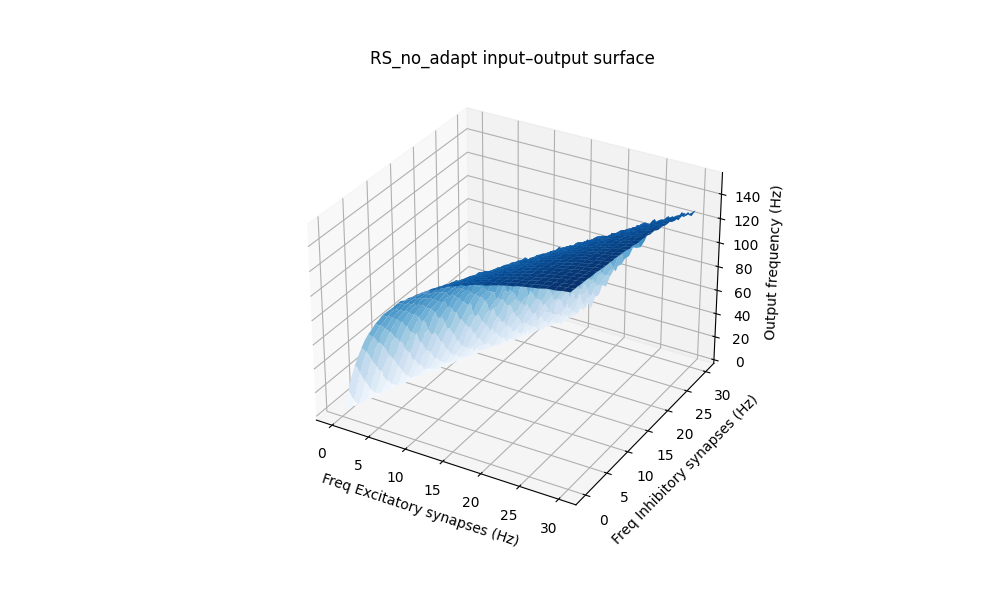

In [30]:
fig = mesh_3d(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS_no_adapt')
figs.append(fig)

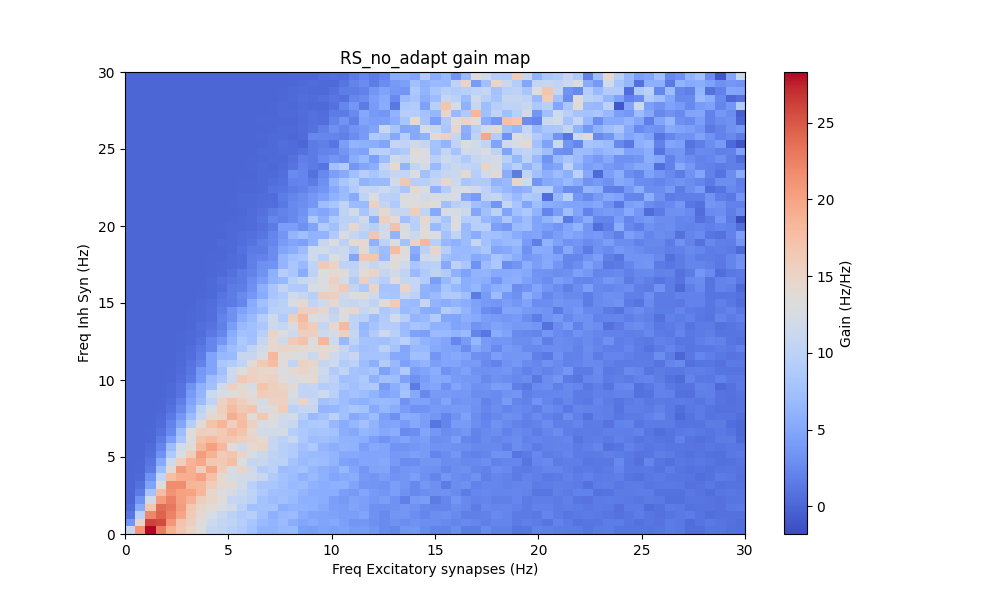

In [31]:
fig = plot_gain(exc_vals, inh_vals, df_RS_slice_array, neuron_type='RS_no_adapt')
figs.append(fig)

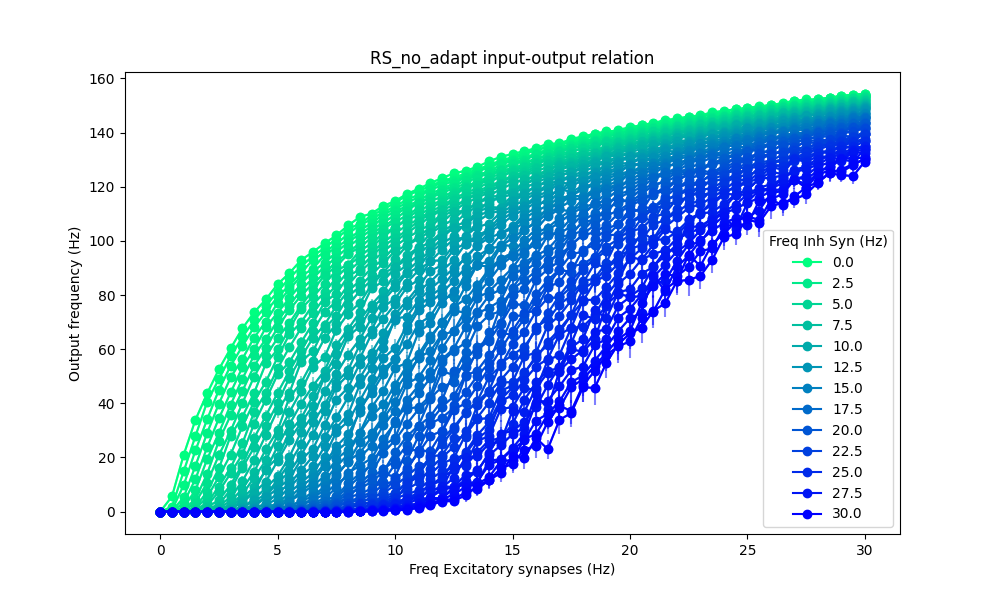

In [32]:
fig = plot_InOut_relation(exc_vals, inh_vals, df_RS_slice_array, df_std_RS_slice_array, neuron_type='RS_no_adapt')
figs.append(fig)

In [33]:
save_figs(fig_path, fig_name, figs)